#  **Machine Learning Analysis of Climate Change Impacts on Global Crop Yields**

## Course: CS 668 – Analytics Capstone Project

# **Team Members**
## Harigopal Chalamalasetty,
## Anuhya Balineni,
## Sowmya Yalavarthi,
##  Sai Ramya Kasumurthy.

### **Load Data and Basic Setup**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load your dataset
df = pd.read_csv('Final dataset.csv')

# Quick overview
print(df.shape)
print(df.info())

(8527, 40)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8527 entries, 0 to 8526
Data columns (total 40 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Scale                                       8527 non-null   object 
 1   Crop                                        8527 non-null   object 
 2   Country                                     8527 non-null   object 
 3   Site(location)                              2609 non-null   object 
 4   Region                                      8527 non-null   object 
 5   latitude                                    8527 non-null   float64
 6   longitude                                   8527 non-null   float64
 7   CAT(dC)_area_weighted                       8527 non-null   float64
 8   CAT_point_coordinate (dC)                   8527 non-null   float64
 9   CAP (mm) _area_weighted                     8527 non-null   int64  
 10  C

### **Handle Missing Values**

In [4]:
# Selecting numeric columns only
numeric_cols = df.select_dtypes(include=np.number).columns

# Impute missing values using median
imputer = SimpleImputer(strategy='median')
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])


In [5]:
# For categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
imputer_cat = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = imputer_cat.fit_transform(df[categorical_cols])


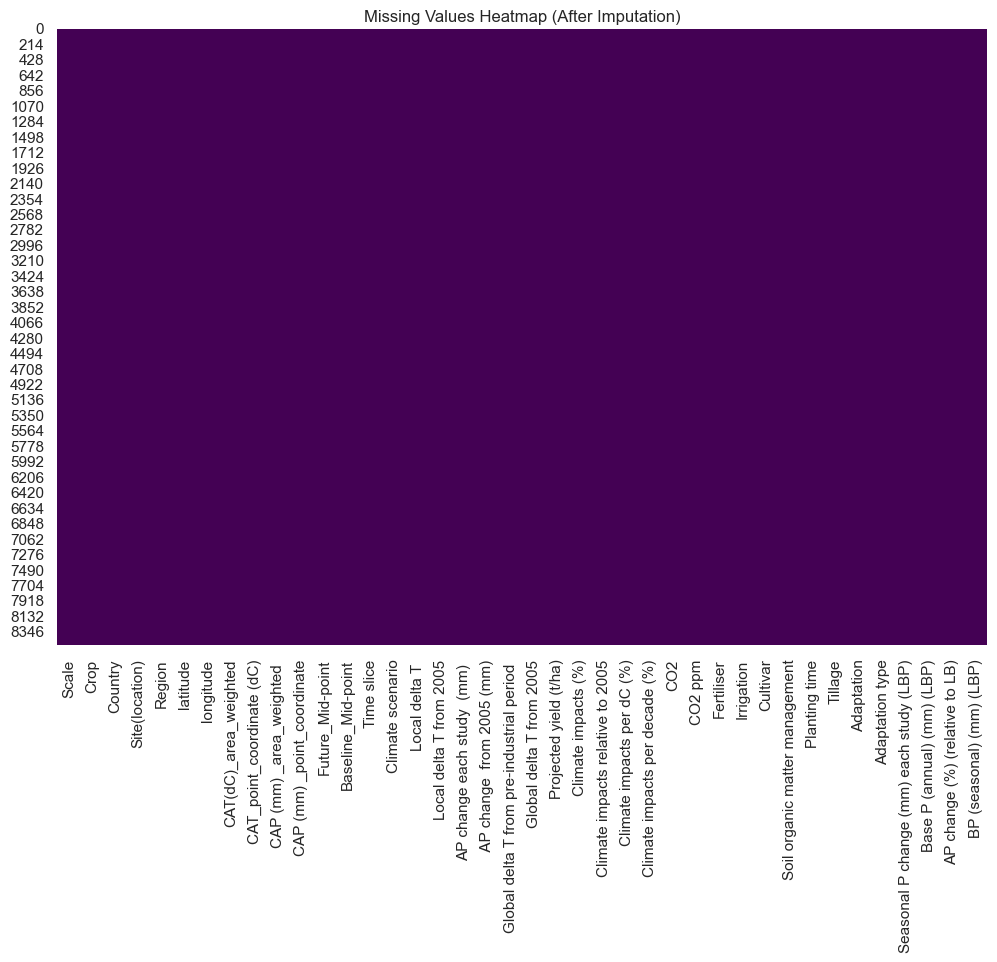

<Figure size 1400x800 with 0 Axes>

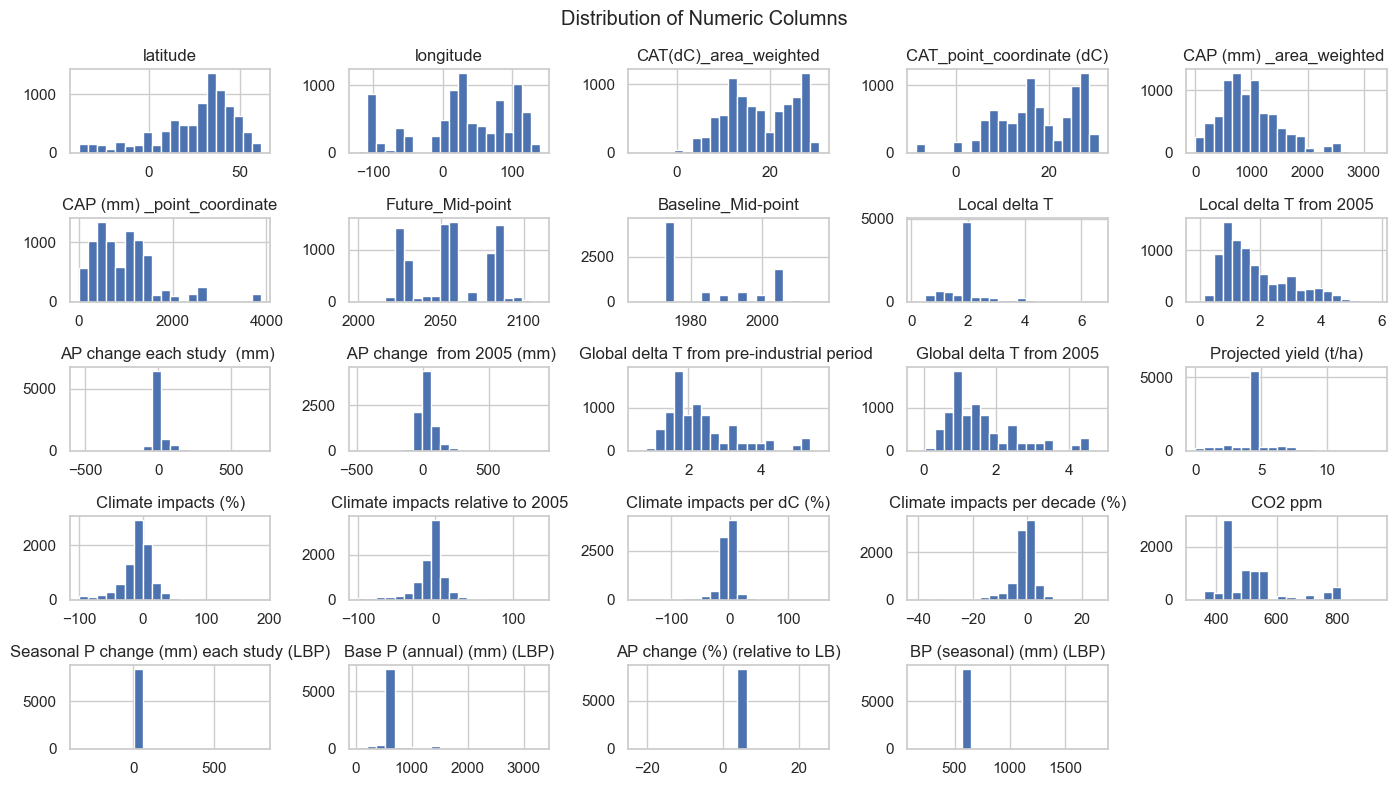

In [6]:
# Set seaborn style
sns.set(style="whitegrid")

# Plot a heatmap to show missing values (after imputation, there should be none)
plt.figure(figsize=(12, 8))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap (After Imputation)')
plt.show()

# Plot distribution of numeric columns to understand their spread
plt.figure(figsize=(14, 8))
df[numeric_cols].hist(bins=20, figsize=(14, 8), layout=(5, 5))
plt.suptitle('Distribution of Numeric Columns')
plt.tight_layout()
plt.show()

### **Detect and Remove Outliers Using Isolation Forest (unsupervised)**

In [8]:
# Scale the numeric data first
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[numeric_cols])

# Isolation Forest to detect outliers
iso = IsolationForest(contamination=0.05, random_state=42)
outliers = iso.fit_predict(scaled_data)

# Remove outliers (-1 means outlier)
df['outlier'] = outliers
df_clean = df[df['outlier'] == 1].drop(columns='outlier')

print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_clean.shape}")

Original shape: (8527, 41)
Cleaned shape: (8100, 40)


### **Exploratory Data Analysis**

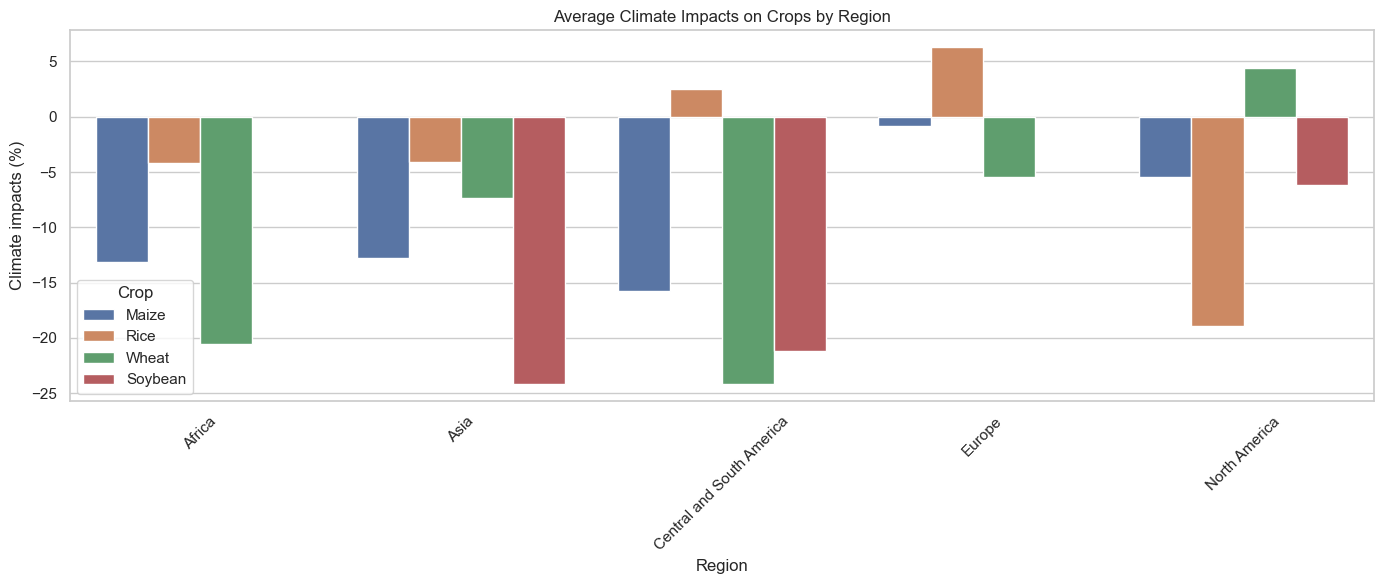

In [10]:
# Average climate impact by crop and region
impact_by_crop_region = df.groupby(['Region', 'Crop'])['Climate impacts (%)'].mean().reset_index()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
sns.barplot(data=impact_by_crop_region, x='Region', y='Climate impacts (%)', hue='Crop')
plt.title("Average Climate Impacts on Crops by Region")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### **Which crop gets the most yield during climate changes**

In [12]:
# Average yield per crop
yield_per_crop = df.groupby('Crop')['Projected yield (t/ha)'].mean().sort_values(ascending=False)

print("Average Projected Yield per Crop:\n", yield_per_crop)

Average Projected Yield per Crop:
 Crop
Rice       4.644254
Maize      4.338573
Wheat      4.089341
Soybean    2.716210
Name: Projected yield (t/ha), dtype: float64


### **How many crops in each region And How many countries**

In [14]:
# Number of unique crops per region
crops_per_region = df.groupby('Region')['Crop'].nunique()

# Number of unique countries
num_countries = df['Country'].nunique()

# Number of countries per region
countries_per_region = df.groupby('Region')['Country'].nunique()

print("Crops per Region:\n", crops_per_region)
print("\nTotal Unique Countries:", num_countries)
print("\nCountries per Region:\n", countries_per_region)


Crops per Region:
 Region
Africa                       3
Asia                         4
Central and South America    4
Europe                       3
North America                4
Name: Crop, dtype: int64

Total Unique Countries: 95

Countries per Region:
 Region
Africa                       32
Asia                         26
Central and South America     5
Europe                       31
North America                 2
Name: Country, dtype: int64


### **Most Affected Crops in Vulnerable Climate Regions (Bar Plot)**

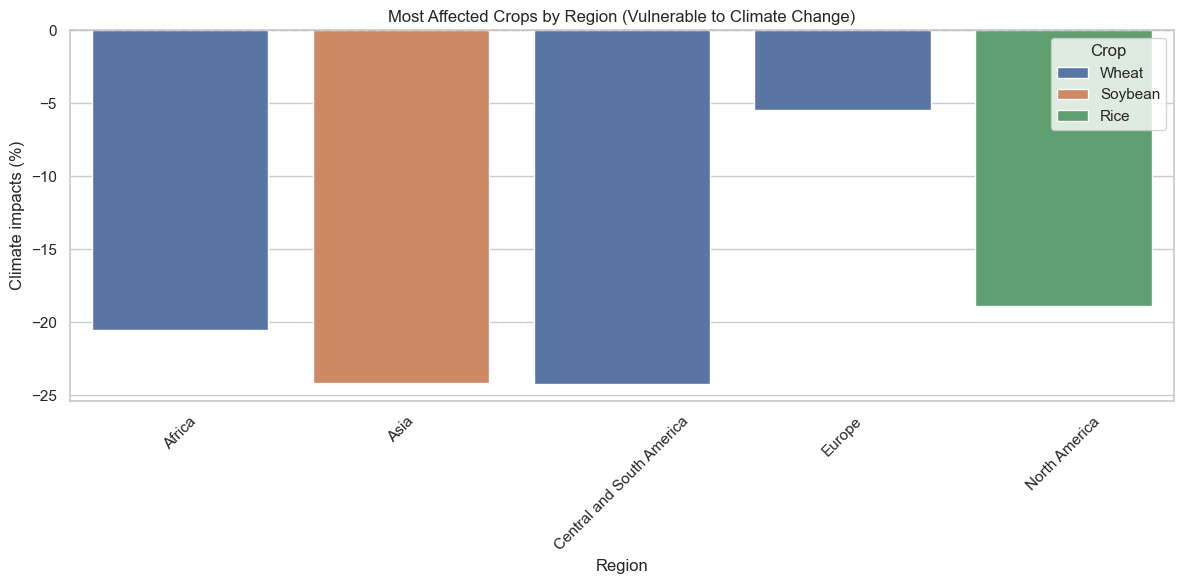

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Group by region and crop, calculate mean climate impact
impact_df = df.groupby(['Region', 'Crop'])['Climate impacts (%)'].mean().reset_index()

# Sort to get the most negatively impacted crop in each region
most_affected = impact_df.sort_values(['Region', 'Climate impacts (%)'])

# Pick the most negatively affected crop per region
most_affected_per_region = most_affected.groupby('Region').first().reset_index()

# Bar plot
plt.figure(figsize=(12, 6))
sns.barplot(data=most_affected_per_region, x='Region', y='Climate impacts (%)', hue='Crop')
plt.title("Most Affected Crops by Region (Vulnerable to Climate Change)")
plt.xticks(rotation=45)
plt.axhline(0, color='gray', linestyle='--')  # line for neutral impact
plt.tight_layout()
plt.show()


### **Crop Analysis**


=== Crop Analysis ===
Total crop types: 4
Crops: ['Maize' 'Rice' 'Soybean' 'Wheat']


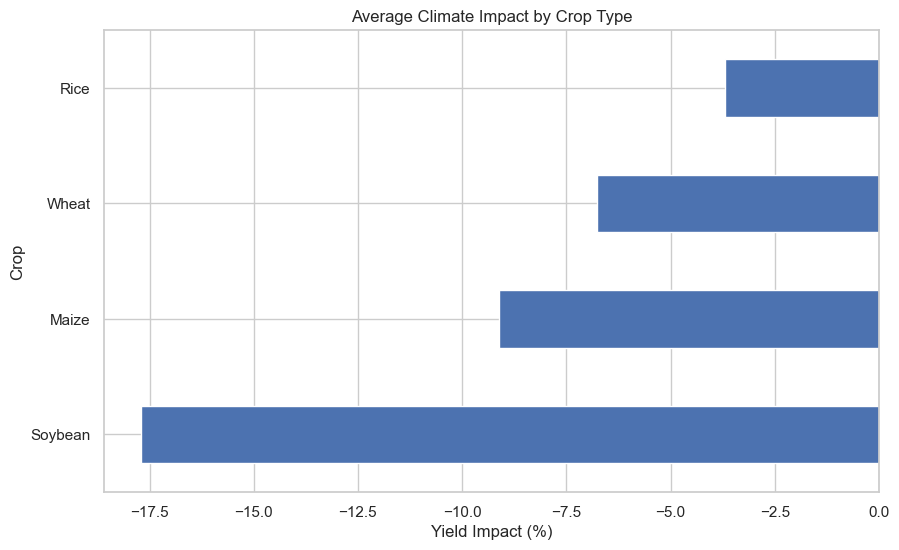

In [18]:
print("\n=== Crop Analysis ===")
print(f"Total crop types: {df['Crop'].nunique()}")
print("Crops:", df['Crop'].unique())

crop_impact = df.groupby('Crop')['Climate impacts (%)'].mean().sort_values()
crop_impact.plot(kind='barh', figsize=(10,6))
plt.title('Average Climate Impact by Crop Type')
plt.xlabel('Yield Impact (%)')
plt.show()


=== CO2 Impact Analysis ===


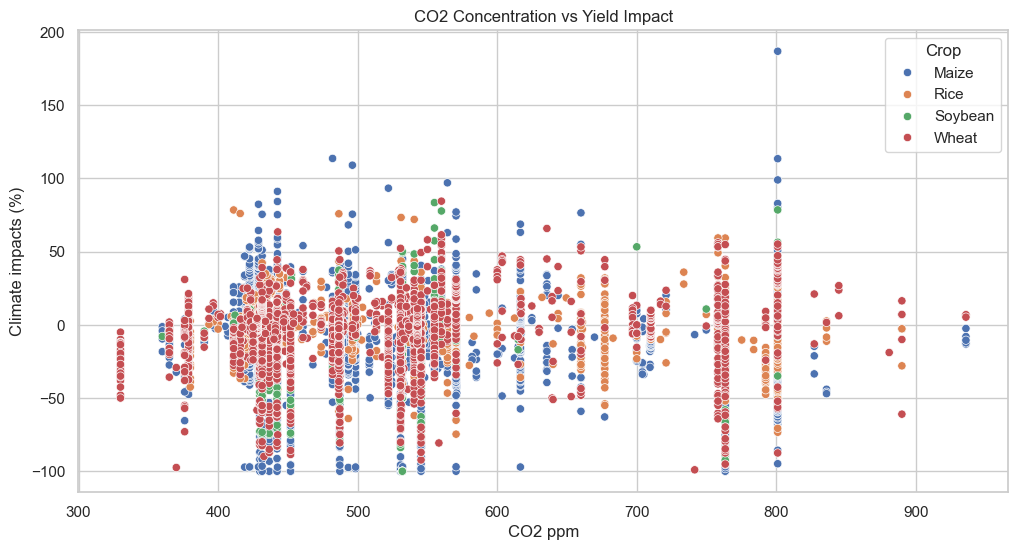

Maize: CO2 vs Impact correlation = -0.18
Rice: CO2 vs Impact correlation = -0.17
Soybean: CO2 vs Impact correlation = 0.04
Wheat: CO2 vs Impact correlation = 0.10


In [19]:
# 3. CO2 Impact Analysis
print("\n=== CO2 Impact Analysis ===")
plt.figure(figsize=(12,6))
sns.scatterplot(x='CO2 ppm', y='Climate impacts (%)', hue='Crop', data=df)
plt.title('CO2 Concentration vs Yield Impact')
plt.show()

# Calculate correlation between CO2 and yield impact for each crop
for crop in df['Crop'].unique():
    crop_df = df[df['Crop'] == crop]
    corr = crop_df['CO2 ppm'].corr(crop_df['Climate impacts (%)'])
    print(f"{crop}: CO2 vs Impact correlation = {corr:.2f}")

In [20]:
# Generate insights
print("\n=== Key Insights ===")

# 1. Regional Analysis
region_impact = df.groupby('Region')['Climate impacts (%)'].mean().sort_values(ascending=False)
print("\nMost affected regions:")
print(region_impact.head(3))


=== Key Insights ===

Most affected regions:
Region
North America   -1.653340
Europe          -1.918590
Asia            -8.690682
Name: Climate impacts (%), dtype: float64


In [22]:
# 2. Crop Vulnerability
crop_vulnerability = df.groupby('Crop')['Climate impacts (%)'].mean().sort_values(ascending=False)
print("\nMost vulnerable crops:")
print(crop_vulnerability.head(3))


Most vulnerable crops:
Crop
Rice    -3.697120
Wheat   -6.767973
Maize   -9.106243
Name: Climate impacts (%), dtype: float64


In [26]:
# 3. CO2 Threshold Analysis
co2_thresholds = []
for crop in df['Crop'].unique():
    threshold = df[df['Crop']==crop]['CO2 ppm'].median()
    co2_thresholds.append((crop, threshold))
print("\nMedian CO2 levels by crop:")
print(pd.DataFrame(co2_thresholds, columns=['Crop', 'Median CO2 (ppm)']))


Median CO2 levels by crop:
      Crop  Median CO2 (ppm)
0    Maize             458.9
1     Rice             487.2
2  Soybean             522.0
3    Wheat             486.5


In [27]:
hotspots = df[(df['Local delta T '] > df['Local delta T '].quantile(0.75)) & 
              (df['AP change each study  (mm) '] < 0)]  # Adjust if necessary
print(f"\nDrought hotspots (high temp increase + precipitation decrease): {len(hotspots)} locations")
print(hotspots[['Region', 'Country', 'Crop']].drop_duplicates())


Drought hotspots (high temp increase + precipitation decrease): 487 locations
                         Region        Country   Crop
55                         Asia          China  Maize
68    Central and South America         Brazil  Maize
111                        Asia           Iran  Maize
578                      Europe        Austria  Maize
590                      Europe        Croatia  Maize
...                         ...            ...    ...
7714                     Europe        Ukraine  Wheat
8064                       Asia      Kazakstan  Wheat
8092                     Europe         Serbia  Wheat
8333              North America  United States  Wheat
8461                     Europe         Russia  Wheat

[68 rows x 3 columns]


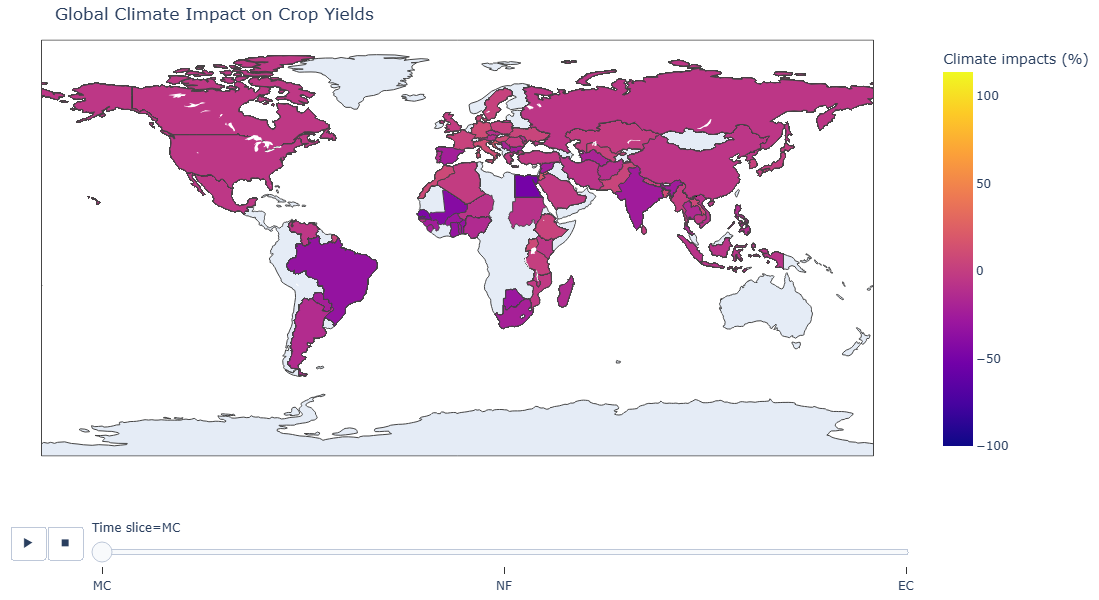

In [89]:
# Interactive regional analysis
import plotly.express as px
fig = px.choropleth(df, 
                    locations='Country',
                    locationmode='country names',
                    color='Climate impacts (%)',
                    hover_name='Crop',
                    animation_frame='Time slice',  # if available
                    title='Global Climate Impact on Crop Yields')
# Make the map bigger
fig.update_layout(
    width=1000,   # increase width
    height=600,   # increase height
    margin=dict(l=0, r=0, t=40, b=0)  # optional: remove extra white space
)
fig.show()

RECORDS PER REGION:
Region
Asia                         3547
Europe                       1951
Africa                       1313
North America                 943
Central and South America     773
Name: count, dtype: int64


C:\Users\kvche\AppData\Local\Temp\ipykernel_20848\3224000879.py:11: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




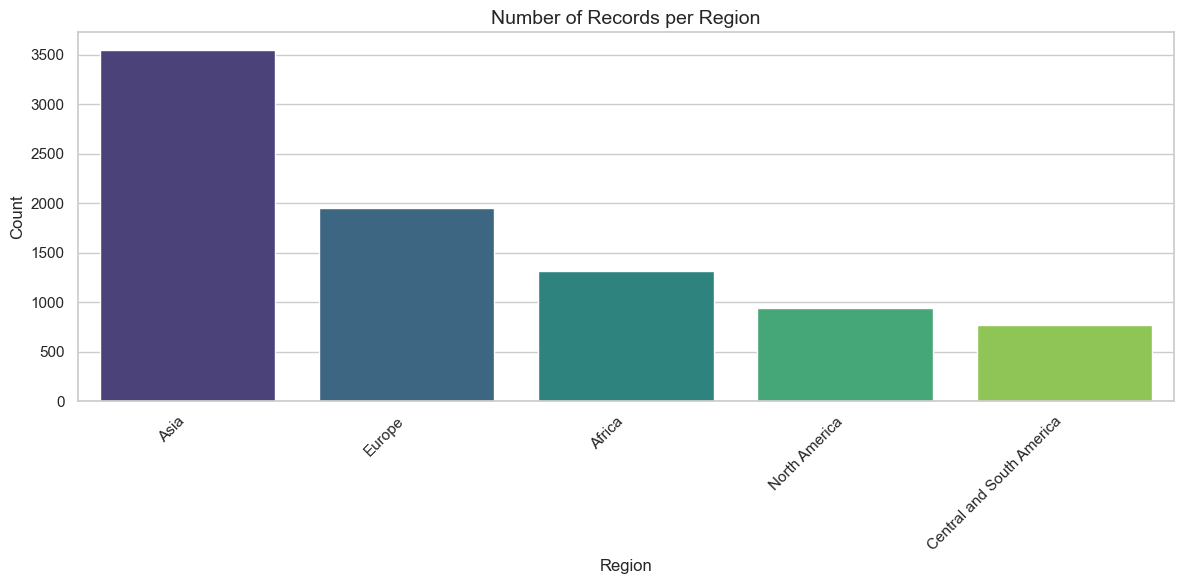

In [29]:
# 1. Count records per region
region_counts = df['Region'].value_counts().sort_values(ascending=False)

print("="*50)
print("RECORDS PER REGION:")
print(region_counts)
print("="*50)

# 2. Visualize region distribution
plt.figure(figsize=(12,6))
sns.barplot(x=region_counts.index, y=region_counts.values, palette="viridis")
plt.title("Number of Records per Region", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### **Show crop distribution per region**

In [31]:
print("\nCROP DISTRIBUTION PER REGION:")
crop_region = pd.crosstab(df['Region'], df['Crop'])
print(crop_region)


CROP DISTRIBUTION PER REGION:
Crop                       Maize  Rice  Soybean  Wheat
Region                                                
Africa                       951   143        0    219
Asia                        1378  1240       84    845
Central and South America    518    28      124    103
Europe                      1296    76        0    579
North America                427    27       84    405


### **Climate Statistics per region**

In [33]:
 print("\nCLIMATE STATISTICS PER REGION:")
climate_stats = df.groupby('Region')[[
    'CAT(dC)_area_weighted',
    'CAP (mm) _area_weighted ',
    'Local delta T '
]].agg(['mean', 'std', 'count'])
print(climate_stats)


CLIMATE STATISTICS PER REGION:
                          CAT(dC)_area_weighted                  \
                                           mean       std count   
Region                                                            
Africa                                22.685301  3.379684  1313   
Asia                                  20.132647  7.414357  3547   
Central and South America             22.406727  3.020012   773   
Europe                                11.063455  2.771343  1951   
North America                         12.306045  4.813979   943   

                          CAP (mm) _area_weighted                     \
                                              mean         std count   
Region                                                                 
Africa                                  844.351866  471.615178  1313   
Asia                                   1108.983366  684.471870  3547   
Central and South America              1335.045278  354.914482   773   

### **Correlation Heatmap**

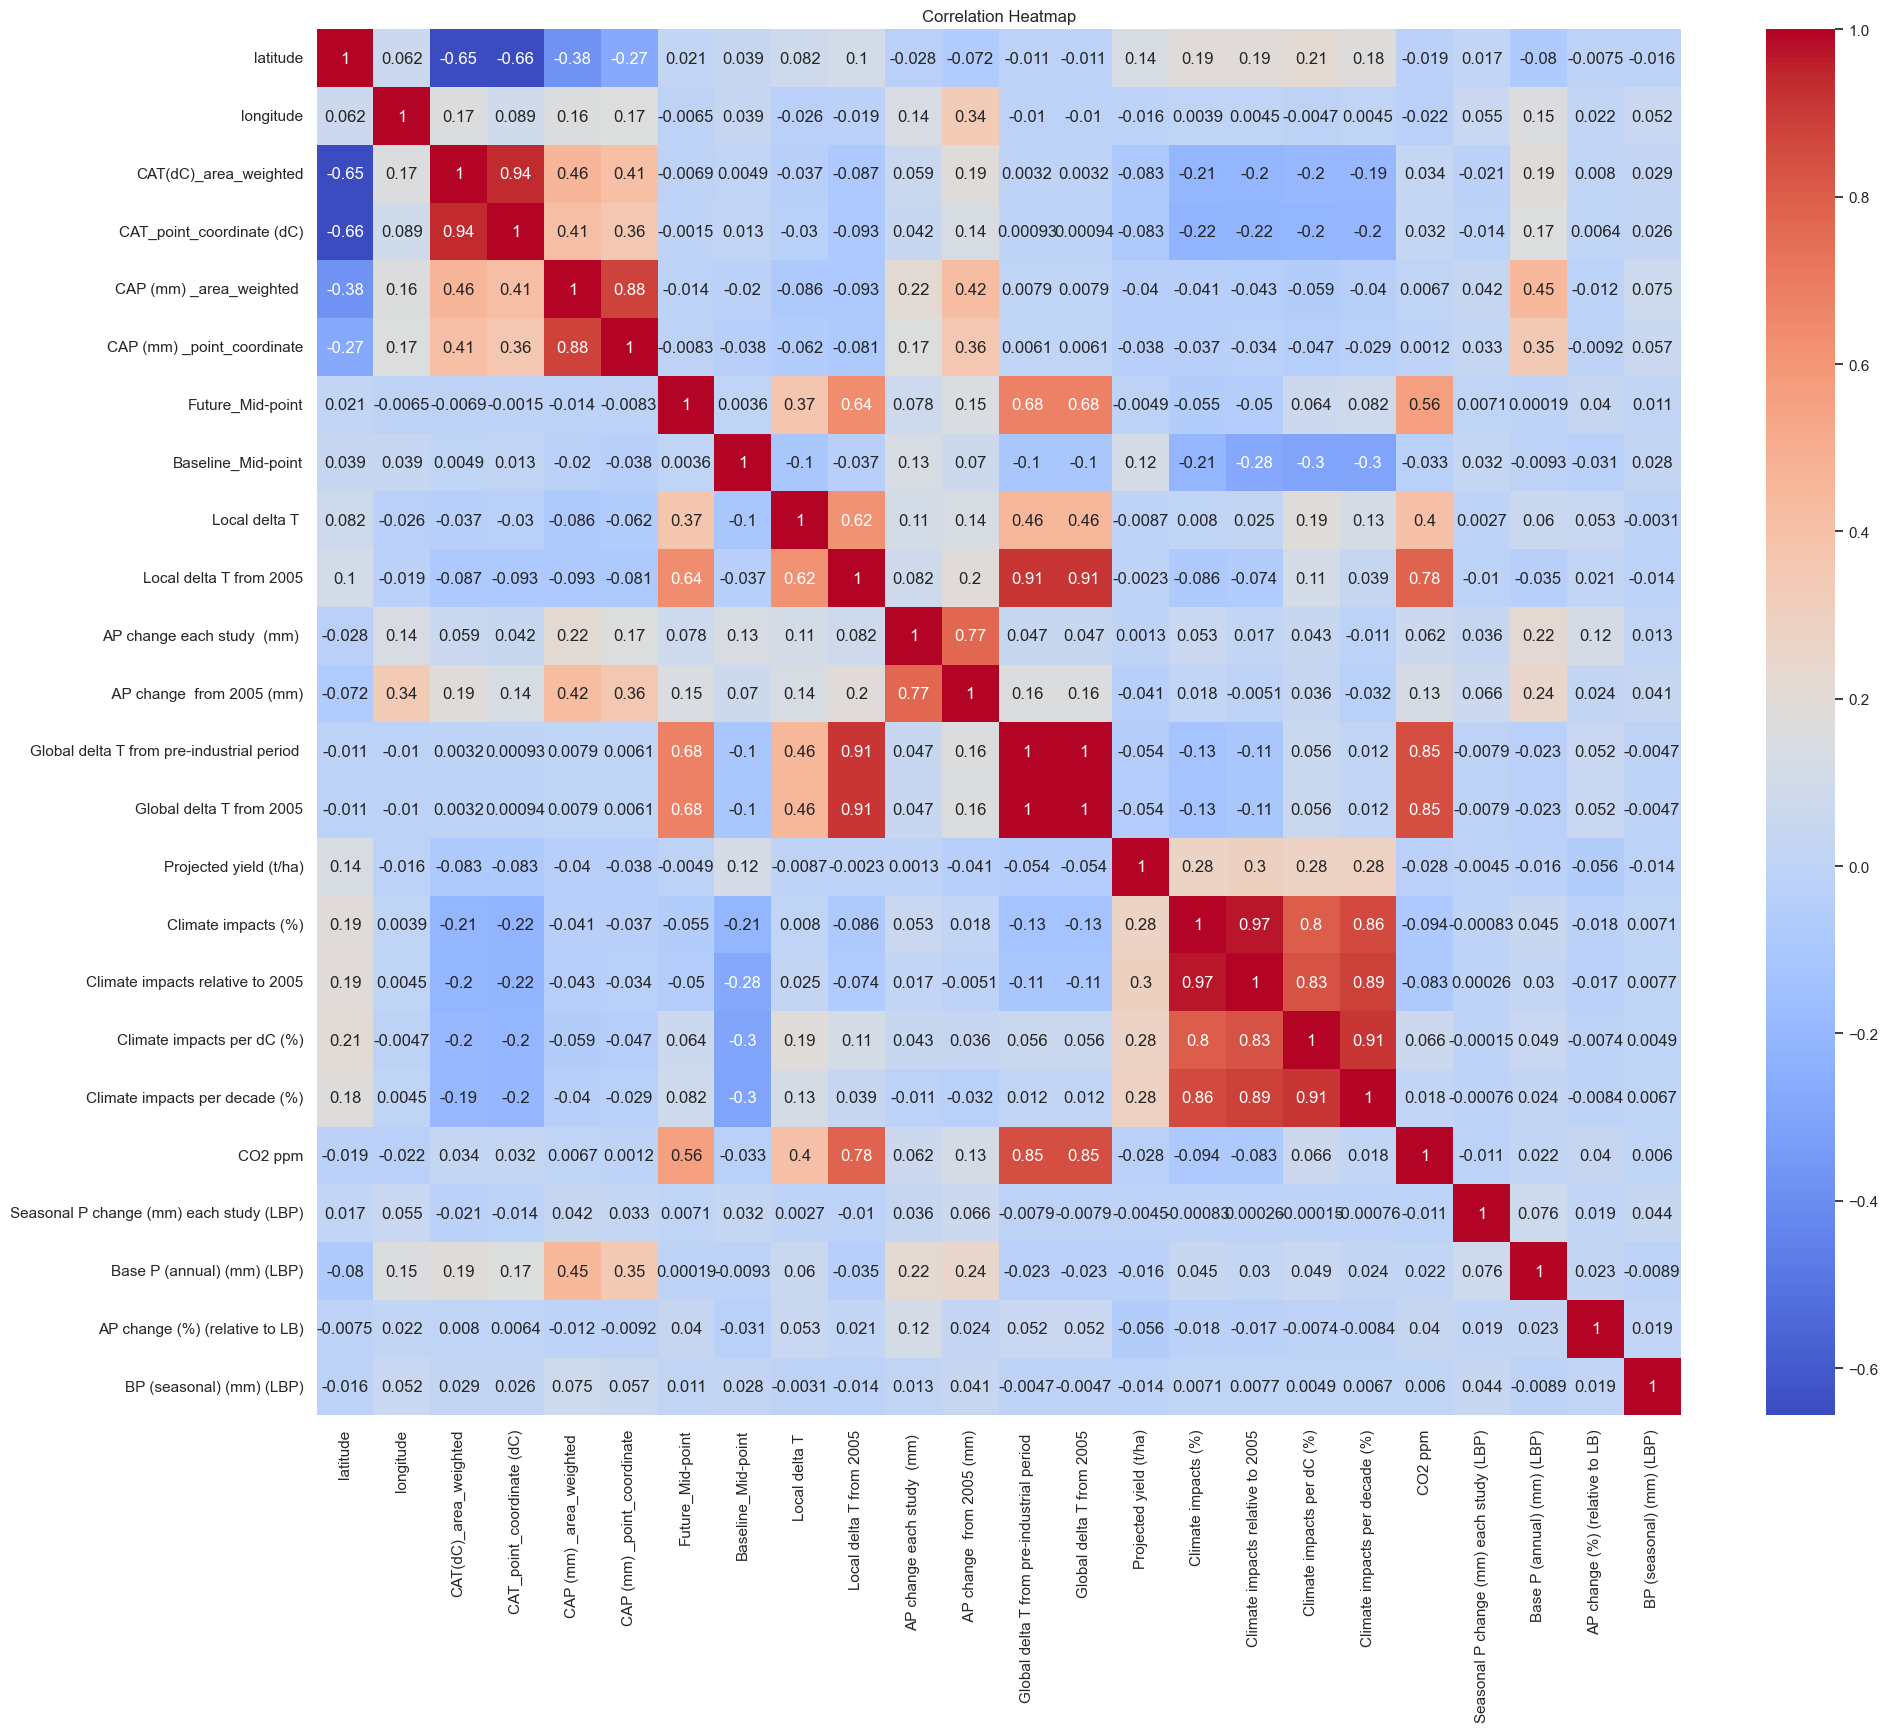

In [35]:
# Correlation heatmap
import seaborn as sns
plt.figure(figsize=(22,18))
sns.heatmap(df.select_dtypes(include=['float64', 'int64']).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## **Feature Engineering**

### **Method 1: Low Variance Filter**

In [38]:
# Remove features with low variance
selector = VarianceThreshold(threshold=0.01)
df_reduced = selector.fit_transform(df_clean[numeric_cols])
selected_features_1 = df_clean[numeric_cols].columns[selector.get_support()]
print("Low Variance Selected Features:", selected_features_1.tolist())

Low Variance Selected Features: ['latitude', 'longitude', 'CAT(dC)_area_weighted', 'CAT_point_coordinate (dC)', 'CAP (mm) _area_weighted ', 'CAP (mm) _point_coordinate', 'Future_Mid-point', 'Baseline_Mid-point', 'Local delta T ', 'Local delta T from 2005', 'AP change each study  (mm) ', ' AP change  from 2005 (mm)', 'Global delta T from pre-industrial period ', 'Global delta T from 2005', 'Projected yield (t/ha)', 'Climate impacts (%)', 'Climate impacts relative to 2005', 'Climate impacts per dC (%)', 'Climate impacts per decade (%)', 'CO2 ppm', 'Seasonal P change (mm) each study (LBP)', 'Base P (annual) (mm) (LBP)', 'AP change (%) (relative to LB)', 'BP (seasonal) (mm) (LBP)']


### **Method 2: PCA (for dimensionality insights)**

In [40]:
# Apply PCA to understand variance explained
pca = PCA(n_components=0.95)  # Retain 95% variance
pca_data = pca.fit_transform(scaled_data)
print(f"Selected {pca.n_components_} components that explain 95% variance")

Selected 15 components that explain 95% variance


### **Method 3: Correlation Filter (manually or via unsupervised selection)**

In [42]:
# Correlation Matrix
corr_matrix = df_clean[numeric_cols].corr().abs()

# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation > 0.9
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
df_clean_reduced = df_clean.drop(columns=to_drop)
print(f"Highly correlated features dropped: {to_drop}")


Highly correlated features dropped: ['CAT_point_coordinate (dC)', 'Global delta T from pre-industrial period ', 'Global delta T from 2005', 'Climate impacts relative to 2005', 'Climate impacts per decade (%)']


### **Final Code to Drop These Features:**

In [44]:
# Drop highly correlated features
features_to_drop = [
    'CAT_point_coordinate (dC)', 
    'Global delta T from pre-industrial period ', 
    'Global delta T from 2005', 
    'Climate impacts relative to 2005', 
    'Climate impacts per decade (%)'
]

df.drop(columns=features_to_drop, inplace=True)


### **Save region-wise data for modeling**

In [46]:
# 5. Save region-wise data for modeling
regions = df['Region'].unique()
for region in regions:
    region_df = df[df['Region'] == region]
    print(f"\nRegion '{region}': {len(region_df)} records")
    print(f"Crops present: {region_df['Crop'].unique()}")
    region_df.to_csv(f"region_{region.lower().replace(' ','_')}_data.csv", index=False)


Region 'Asia': 3547 records
Crops present: ['Maize' 'Rice' 'Soybean' 'Wheat']

Region 'North America': 943 records
Crops present: ['Maize' 'Rice' 'Soybean' 'Wheat']

Region 'Africa': 1313 records
Crops present: ['Maize' 'Rice' 'Wheat']

Region 'Central and South America': 773 records
Crops present: ['Maize' 'Rice' 'Soybean' 'Wheat']

Region 'Europe': 1951 records
Crops present: ['Maize' 'Rice' 'Wheat']


In [47]:
# Remove 'Global' and 'Australasia' regions from the dataset
df = df[~df['Region'].isin(['Global', 'Australasia'])]

# Check the remaining unique regions
print("Remaining Regions:\n", df['Region'].unique())

Remaining Regions:
 ['Asia' 'North America' 'Africa' 'Central and South America' 'Europe']


Most Affected Crop: Rice
Regions with Highest Yields:
 Region
Europe           4.609293
North America    4.539129
Asia             4.226825
Name: Projected yield (t/ha), dtype: float64
Climate in High-Yield Regions:
                CAT(dC)_area_weighted  CAP (mm) _area_weighted 
Region                                                        
Asia                       20.132647               1108.983366
Europe                     11.063455                756.859047
North America              12.306045                885.502651


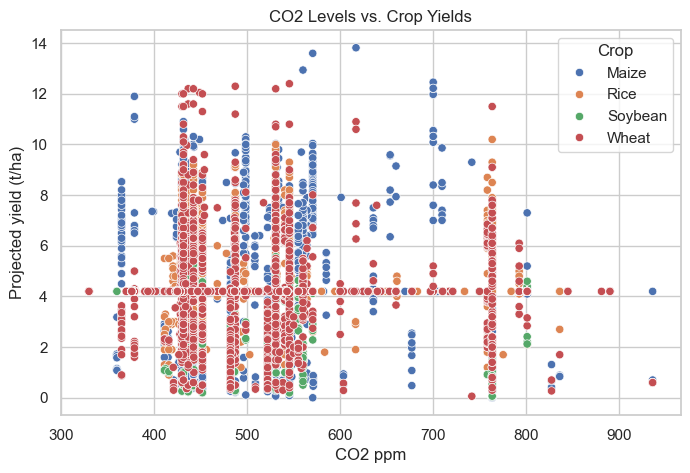

In [48]:
# Most affected crop
most_affected_crop = df.groupby('Crop')['Climate impacts (%)'].mean().idxmax()
print(f"Most Affected Crop: {most_affected_crop}")

# --- Q3: Regions with highest yields & their climate ---
high_yield_regions = df.groupby('Region')['Projected yield (t/ha)'].mean().sort_values(ascending=False).head(3)
print("Regions with Highest Yields:\n", high_yield_regions)

# Climate conditions in these regions
high_yield_climate = df[df['Region'].isin(high_yield_regions.index)].groupby('Region')[['CAT(dC)_area_weighted', 'CAP (mm) _area_weighted ',]].mean()
print("Climate in High-Yield Regions:\n", high_yield_climate)

# --- Q4: CO2 vs. Yields ---
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='CO2 ppm', y='Projected yield (t/ha)', hue='Crop')
plt.title("CO2 Levels vs. Crop Yields")
plt.show()


Maize yield decline per degree temperature increase:
Slope: -0.042 t/ha/°C (95% CI: -0.049--0.035)


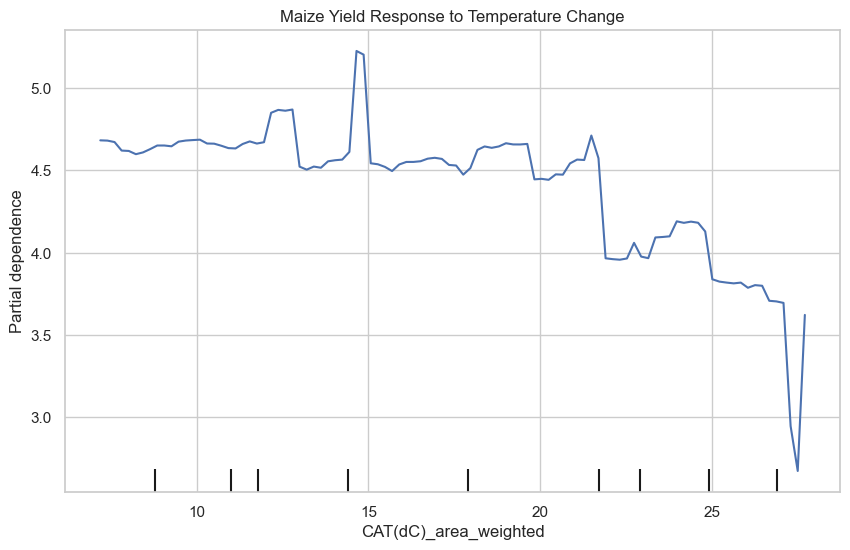

In [99]:
# 1. Data Cleaning - Handle mixed types and missing values
def clean_numeric(col):
    return pd.to_numeric(col, errors='coerce')

numeric_cols = ['CAT(dC)_area_weighted', 'CAP (mm) _area_weighted ',
               'Local delta T ', 'CO2 ppm', 'Projected yield (t/ha)',
               'Climate impacts (%)', 'AP change each study  (mm) ']

for col in numeric_cols:
    df[col] = clean_numeric(df[col])

# Remove rows with missing target values
df = df.dropna(subset=['Projected yield (t/ha)'])

# 2. Maize Temperature Response Analysis
maize_df = df[df['Crop'] == 'Maize'].copy()

if len(maize_df) > 0:
    # Prepare features - ensure numeric
    X_maize = maize_df[numeric_cols[:4]].fillna(maize_df[numeric_cols[:4]].mean())
    y_maize = maize_df['Projected yield (t/ha)']
    
    # Fit Random Forest model
    rf_maize = RandomForestRegressor(n_estimators=500, random_state=42)
    rf_maize.fit(X_maize, y_maize)

    # Calculate temperature impact
    print("\nMaize yield decline per degree temperature increase:")
    temp_impact = stats.linregress(
        maize_df['CAT(dC)_area_weighted'],
        maize_df['Projected yield (t/ha)']
    )
    print(f"Slope: {temp_impact.slope:.3f} t/ha/°C (95% CI: {temp_impact.slope-1.96*temp_impact.stderr:.3f}-{temp_impact.slope+1.96*temp_impact.stderr:.3f})")

    # Partial dependence plot for temperature
    fig, ax = plt.subplots(figsize=(10,6))
    PartialDependenceDisplay.from_estimator(
        rf_maize, 
        X_maize, 
        features=['CAT(dC)_area_weighted'],
        ax=ax
    )
    ax.axvline(x=4, color='r', linestyle='--', label='Critical Threshold (+4°C)')
    ax.set_title('Maize Yield Response to Temperature Change')
    ax.set_ylabel('Projected Yield (t/ha)')
    ax.set_xlabel('Temperature Change (dC)')
    plt.savefig('maize_temp_response.png')

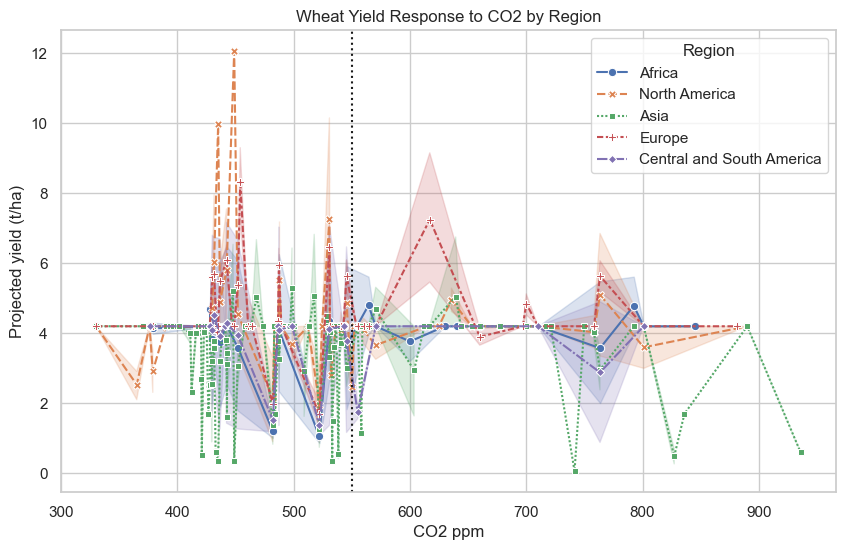

In [103]:
# 3. Wheat CO2 Analysis
wheat_df = df[df['Crop'] == 'Wheat'].copy()

if len(wheat_df) > 0:
    wheat_df = wheat_df.dropna(subset=['CO2 ppm', 'Projected yield (t/ha)'])
    
    # CO2 response by region
    co2_bins = np.arange(350, 650, 50)
    wheat_df['CO2_bin'] = pd.cut(wheat_df['CO2 ppm'], bins=co2_bins)
    
    # Plot CO2 response
    plt.figure(figsize=(10,6))
    sns.lineplot(
        data=wheat_df,
        x='CO2 ppm', 
        y='Projected yield (t/ha)',
        hue='Region',
        style='Region',
        markers=True
    )
    plt.axvline(x=550, color='k', linestyle=':', label='CO2 Saturation Point')
    plt.title('Wheat Yield Response to CO2 by Region')
    plt.savefig('wheat_co2_response.png')



In [105]:
# 4. Rice Flooding Impact
rice_df = df[df['Crop'] == 'Rice'].copy()

if len(rice_df) > 0:
    rice_df = rice_df.dropna(subset=['AP change each study  (mm) ', 'Projected yield (t/ha)'])
    flood_threshold = rice_df['AP change each study  (mm) '].quantile(0.9)
    rice_df['Flooding'] = rice_df['AP change each study  (mm) '] > flood_threshold

    print("\nRice yield difference during flood events:")
    print(rice_df.groupby('Flooding')['Projected yield (t/ha)'].agg(['mean', 'sem']))




Rice yield difference during flood events:
              mean       sem
Flooding                    
False     4.627140  0.035826
True      4.803401  0.170640



Soybean average climate impact: -17.7%


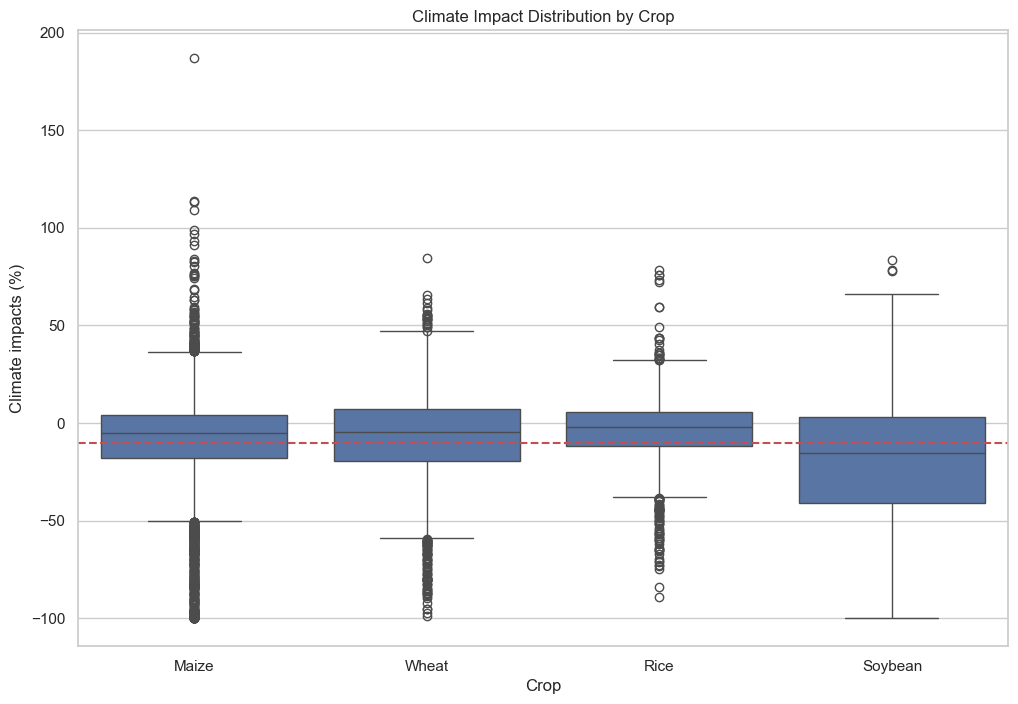

In [107]:
# 5. Soybean Analysis
soy_df = df[df['Crop'] == 'Soybean'].copy()

if len(soy_df) > 0:
    soy_df = soy_df.dropna(subset=['Climate impacts (%)'])
    print(f"\nSoybean average climate impact: {soy_df['Climate impacts (%)'].mean():.1f}%")
    
    # Combined Climate Impact Plot
    plt.figure(figsize=(12,8))
    plot_df = df[df['Crop'].isin(['Maize', 'Wheat', 'Rice', 'Soybean'])].dropna(subset=['Climate impacts (%)'])
    sns.boxplot(
        x='Crop',
        y='Climate impacts (%)',
        data=plot_df,
        order=['Maize', 'Wheat', 'Rice', 'Soybean']
    )
    plt.axhline(y=-10, color='r', linestyle='--', label='Soybean Benchmark')
    plt.title('Climate Impact Distribution by Crop')
    plt.savefig('crop_impact_comparison.png')

In [49]:
# Print all column names to check if the correct ones are present
print(df.columns)

Index(['Scale', 'Crop', 'Country', 'Site(location)', 'Region', 'latitude',
       'longitude', 'CAT(dC)_area_weighted', 'CAP (mm) _area_weighted ',
       'CAP (mm) _point_coordinate', 'Future_Mid-point', 'Baseline_Mid-point',
       'Time slice', 'Climate scenario', 'Local delta T ',
       'Local delta T from 2005', 'AP change each study  (mm) ',
       ' AP change  from 2005 (mm)', 'Projected yield (t/ha)',
       'Climate impacts (%)', 'Climate impacts per dC (%)', 'CO2', 'CO2 ppm',
       'Fertiliser', 'Irrigation', 'Cultivar',
       'Soil organic matter management', 'Planting time', 'Tillage',
       'Adaptation', 'Adaptation type',
       'Seasonal P change (mm) each study (LBP)', 'Base P (annual) (mm) (LBP)',
       'AP change (%) (relative to LB)', 'BP (seasonal) (mm) (LBP)',
       'outlier'],
      dtype='object')


In [50]:
# Select features
features = [
    'Region', 'Country', 'Crop', 'Local delta T ', 'Local delta T from 2005',
    'AP change each study  (mm) ', ' AP change  from 2005 (mm)',
    'Climate impacts (%)', 'CO2 ppm', 'Fertiliser', 'Irrigation', 'Cultivar',
    'Soil organic matter management', 'Planting time', 'Tillage', 'Adaptation'
]
target = 'Projected yield (t/ha)'

# Drop rows with missing values in selected columns
model_df = df[features + [target]].dropna()

# Encode categorical features
cat_features = model_df.select_dtypes(include='object').columns
label_encoders = {}

for col in cat_features:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col])
    label_encoders[col] = le

# Feature-target split
X = model_df[features]
y = model_df[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### **Linear Regression**

In [54]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

print("Linear Regression R²:", r2_score(y_test, lr_preds))
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, lr_preds)))

Linear Regression R²: 0.14823501649512227
Linear Regression RMSE: 1.585267877658255


### **XGBoost Regressor**

In [58]:
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

print("XGBoost R²:", r2_score(y_test, xgb_preds))
print("XGBoost RMSE:", np.sqrt(mean_squared_error(y_test, xgb_preds)))

XGBoost R²: 0.7562985708733309
XGBoost RMSE: 0.8479530498845733


### **Random Forest Regressor**

In [63]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("Random Forest R²:", r2_score(y_test, rf_preds))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, rf_preds)))


Random Forest R²: 0.7713126303544466
Random Forest RMSE: 0.8214173243039959


### **EXPLAINABLE AND INTERPRETABLE AI USING SHAP VALUES**

100%|===================| 1703/1706 [03:09<00:00]        

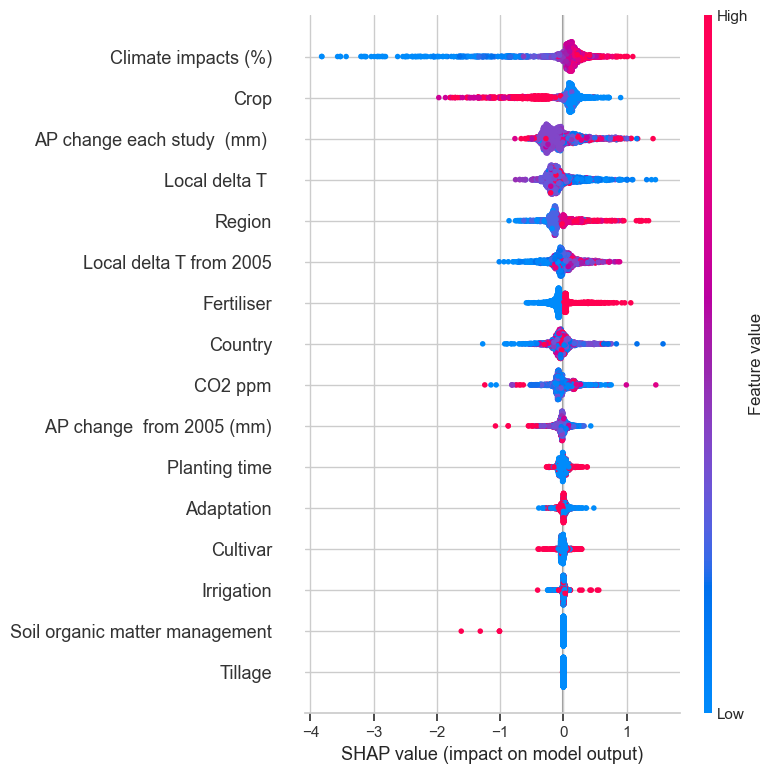

In [70]:
import shap
import matplotlib.pyplot as plt

# Initialize SHAP explainer for tree models
explainer = shap.Explainer(rf_model, X_train)

# Get SHAP values for test data
shap_values = explainer(X_test, check_additivity=False)

# Summary plot to show global feature importance
shap.summary_plot(shap_values, X_test)

# Optional: Interpret a single prediction
shap.plots.force(shap_values[0])  # Visualizes one prediction


In [ ]:
selected_regions = ['Africa','Asia','Europe']
subset_df = df[df['Region'].isin(selected_regions)][features + [target]].dropna()

# Encode & scale again for subset
for col in subset_df.select_dtypes(include='object').columns:
    subset_df[col] = label_encoders[col].transform(subset_df[col])

X_sub = subset_df[features]
y_sub = subset_df[target]

X_train_sub, X_test_sub, y_train_sub, y_test_sub = train_test_split(X_sub, y_sub, test_size=0.2, random_state=42)
X_train_sub_scaled = scaler.fit_transform(X_train_sub)
X_test_sub_scaled = scaler.transform(X_test_sub)

# Train Random Forest on subset
rf_sub_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_sub_model.fit(X_train_sub, y_train_sub)
rf_sub_preds = rf_sub_model.predict(X_test_sub)

print("Subset Random Forest R²:", r2_score(y_test_sub, rf_sub_preds))
print("Subset Random Forest RMSE:", np.sqrt(mean_squared_error(y_test_sub, rf_sub_preds)))

In [204]:
selected_regions = ['Asia','Central and South America','North America']
subset_df = df[df['Region'].isin(selected_regions)][features + [target]].dropna()

# Encode & scale again for subset
for col in subset_df.select_dtypes(include='object').columns:
    subset_df[col] = label_encoders[col].transform(subset_df[col])

X_sub = subset_df[features]
y_sub = subset_df[target]

X_train_sub, X_test_sub, y_train_sub, y_test_sub = train_test_split(X_sub, y_sub, test_size=0.2, random_state=42)
X_train_sub_scaled = scaler.fit_transform(X_train_sub)
X_test_sub_scaled = scaler.transform(X_test_sub)

# Train Random Forest on subset
rf_sub_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_sub_model.fit(X_train_sub, y_train_sub)
rf_sub_preds = rf_sub_model.predict(X_test_sub)

print("Subset Random Forest R²:", r2_score(y_test_sub, rf_sub_preds))
print("Subset Random Forest RMSE:", np.sqrt(mean_squared_error(y_test_sub, rf_sub_preds)))

Subset Random Forest R²: 0.8229505605723123
Subset Random Forest RMSE: 0.7255208659654665


In [187]:
def recommend_crop(region, climate_df=df):
    # Filter data for the given region
    region_data = climate_df[climate_df['Region'] == region]
    
    if region_data.empty:
        return f"No data available for {region}."

    # Get the best performing crop per country
    country_crop_yield = region_data.groupby(['Country', 'Crop'])['Projected yield (t/ha)'].mean().reset_index()
    
    if country_crop_yield.empty:
        return f"No crop yield data available for {region}."

    # Identify the best performing crop for each country
    best_crops_per_country = country_crop_yield.loc[country_crop_yield.groupby('Country')['Projected yield (t/ha)'].idxmax()]
    
    # Calculate average CO2 levels per country
    country_avg_co2 = region_data.groupby('Country')['CO2 ppm'].mean().reset_index()

    # Merge CO2 info with the best crops per country
    best_crops_per_country = pd.merge(best_crops_per_country, country_avg_co2, on='Country', how='left')
    
    # Show the results
    recommendations = best_crops_per_country[['Country', 'Crop', 'Projected yield (t/ha)', 'CO2 ppm']]
    
    return recommendations

# Example usage
print(recommend_crop("Europe"))


                Country   Crop  Projected yield (t/ha)     CO2 ppm
0                Alpine  Maize                4.200000  458.500000
1      Atlantic Central  Maize                4.200000  458.500000
2        Atlantic North  Maize                4.200000  458.500000
3        Atlantic South  Maize                4.200000  458.500000
4               Austria  Maize                4.517318  529.573394
5              Bulgaria  Wheat                3.859655  511.806897
6      Continetal North  Maize                4.200000  458.500000
7      Continetal South  Maize                4.200000  458.500000
8               Croatia  Maize                4.509905  506.053409
9        Czech Republic  Wheat                5.395714  514.803571
10              Denmark  Wheat                5.190357  518.907143
11              Finland  Wheat                4.125000  460.190000
12               France  Wheat                5.464857  503.140994
13              Germany  Wheat                6.094286  510.44

In [131]:
def recommend_crop(region, climate_df=df):
    region_data = climate_df[climate_df['Region'] == region]
    
    if region_data.empty:
        return f"No data available for {region}."

    crop_yields = region_data.groupby('Crop')['Projected yield (t/ha)'].mean()
    
    if crop_yields.empty:
        return f"No crop yield data available for {region}."

    best_crop = crop_yields.idxmax()
    avg_co2 = region_data['CO2 ppm'].mean()
    avg_yield = crop_yields[best_crop]

    return (f"In {region}, {best_crop} performs best "
            f"(avg yield: {avg_yield:.1f} t/ha) at CO2 levels of {avg_co2:.0f} ppm.")
print(recommend_crop("Europe"))

In Europe, Wheat performs best (avg yield: 4.8 t/ha) at CO2 levels of 509 ppm.


In [133]:
def recommend_crop_by_impact(region, climate_df=df):
    region_data = climate_df[climate_df['Region'] == region]
    
    if region_data.empty:
        return f"No data available for {region}."

    crop_impacts = region_data.groupby('Crop')['Climate impacts (%)'].mean()
    
    if crop_impacts.empty:
        return f"No climate impact data available for {region}."

    # Assuming lower impact is better (less damage)
    best_crop = crop_impacts.idxmin()
    avg_co2 = region_data['CO2 ppm'].mean()
    avg_impact = crop_impacts[best_crop]

    return (f"In {region}, {best_crop} is least impacted by climate "
            f"(avg impact: {avg_impact:.1f}%) at CO2 levels of {avg_co2:.0f} ppm.")
print(recommend_crop_by_impact("Europe"))


In Europe, Wheat is least impacted by climate (avg impact: -5.5%) at CO2 levels of 509 ppm.


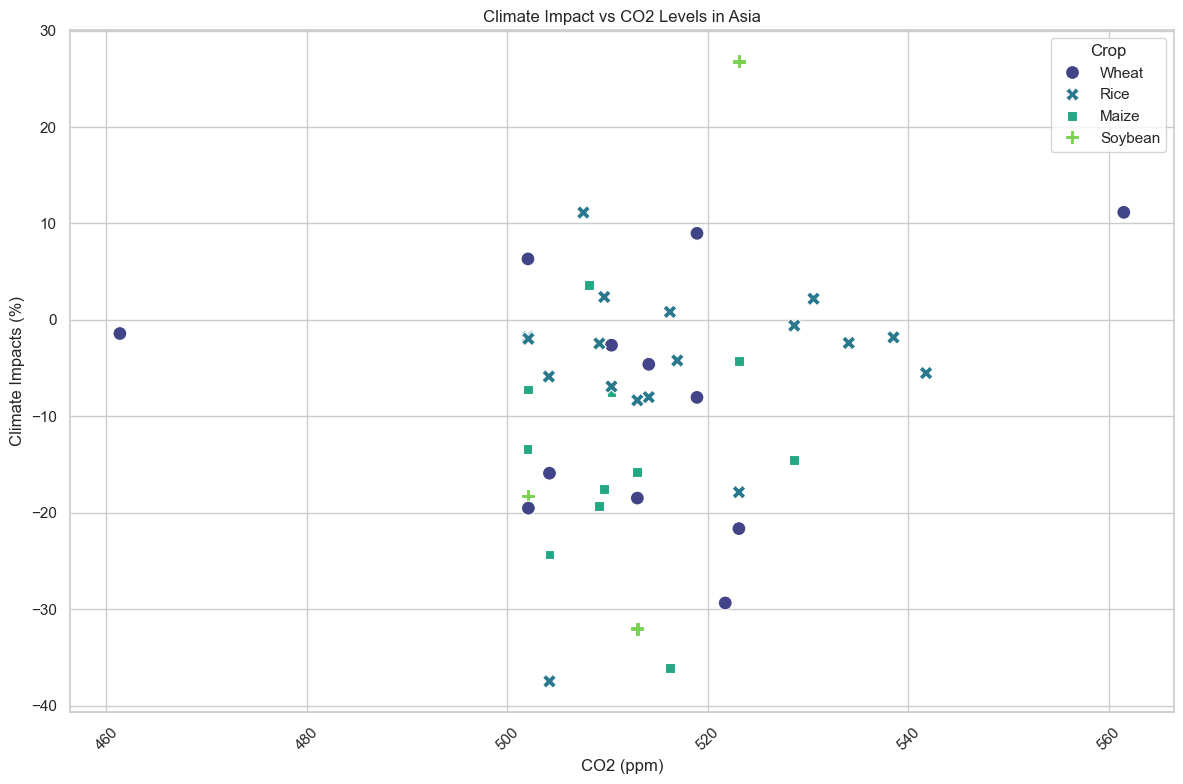

In [197]:
def plot_climate_impact(region, climate_df=df):
    # Filter data for the given region
    region_data = climate_df[climate_df['Region'] == region]
    
    if region_data.empty:
        print(f"No data available for {region}.")
        return

    # Get average climate impact per crop per country
    country_crop_impact = region_data.groupby(['Country', 'Crop'])['Climate impacts (%)'].mean().reset_index()
    
    if country_crop_impact.empty:
        print(f"No climate impact data available for {region}.")
        return

    # Merge average CO2 ppm per country
    country_avg_co2 = region_data.groupby('Country')['CO2 ppm'].mean().reset_index()
    country_crop_impact = pd.merge(country_crop_impact, country_avg_co2, on='Country', how='left')

    # Plot: Scatter plot for climate impact vs CO2 ppm
    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        data=country_crop_impact,
        x='CO2 ppm',
        y='Climate impacts (%)',
        hue='Crop',
        style='Crop',
        palette='viridis',
        s=100
    )
    plt.title(f"Climate Impact vs CO2 Levels in {region}")
    plt.xlabel("CO2 (ppm)")
    plt.ylabel("Climate Impacts (%)")
    plt.xticks(rotation=45)
    plt.legend(title="Crop")
    plt.tight_layout()
    plt.show()

# Example usage
plot_climate_impact("Asia")


In [147]:
def recommend_agricultural_strategies(region, climate_df=df):
    region_data = climate_df[climate_df['Region'] == region]
    
    if region_data.empty:
        return f"No data available for {region}."

    # Calculate metrics for all crops in the region
    crop_stats = region_data.groupby('Crop').agg({
        'Projected yield (t/ha)': 'mean',
        'Climate impacts (%)': 'mean',
        'CO2 ppm': 'mean'
    }).reset_index()
    
    if crop_stats.empty:
        return f"No crop data available for {region}."

    # Farmer recommendation: highest yield
    best_yield_crop = crop_stats.loc[crop_stats['Projected yield (t/ha)'].idxmax()]
    
    # Policymaker recommendation: most climate-resilient (least negative impact)
    best_resilient_crop = crop_stats.loc[crop_stats['Climate impacts (%)'].idxmin()]

    # Generate reports
    farmer_report = (
        f"Recommended for Farmers in {region}:\n"
        f"• Best Performing Crop: {best_yield_crop['Crop']}\n"
        f"  - Average Yield: {best_yield_crop['Projected yield (t/ha)']:.1f} t/ha\n"
        f"  - Climate Impact: {best_yield_crop['Climate impacts (%)']:.1f}%\n"
        f"  - Optimal CO₂: {best_yield_crop['CO2 ppm']:.0f} ppm"
    )
    
    policymaker_report = (
        f"\n\nRecommended for Policymakers in {region}:\n"
        f"• Most Climate-Resilient Crop: {best_resilient_crop['Crop']}\n"
        f"  - Climate Impact: {best_resilient_crop['Climate impacts (%)']:.1f}%\n"
        f"  - Average Yield: {best_resilient_crop['Projected yield (t/ha)']:.1f} t/ha\n"
        f"  - CO₂ Adaptation: {best_resilient_crop['CO2 ppm']:.0f} ppm\n"
        f"• Key Action: {'Promote' if best_resilient_crop['Climate impacts (%)'] < 0 else 'Maintain'} {best_resilient_crop['Crop']} cultivation"
    )

    return farmer_report + policymaker_report

# Example usage
print(recommend_agricultural_strategies("Central and South America"))

Recommended for Farmers in Central and South America:
• Best Performing Crop: Rice
  - Average Yield: 4.3 t/ha
  - Climate Impact: 2.5%
  - Optimal CO₂: 527 ppm

Recommended for Policymakers in Central and South America:
• Most Climate-Resilient Crop: Wheat
  - Climate Impact: -24.2%
  - Average Yield: 3.6 t/ha
  - CO₂ Adaptation: 515 ppm
• Key Action: Promote Wheat cultivation
